# Product Analytics

This notebook analyzes product performance, category contribution, pricing patterns, and freight costs to identify the products and categories driving business growth.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
orderitems = pd.read_csv("../data/engineered/orderitems_engineered.csv")
products = pd.read_csv("../data/engineered/products_engineered.csv")
categories = pd.read_csv("../data/engineered/categories_engineered.csv")

## Business Objective

The objective of this notebook is to evaluate product performance by analyzing sales, pricing, product categories, and freight costs. The insights generated will support inventory planning, pricing strategies, and product portfolio optimization.

## Product Category Distribution

In [4]:
category_count = (
    products["product_category_name"]
    .value_counts()
    .head(10)
)

category_count

cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: product_category_name, dtype: int64

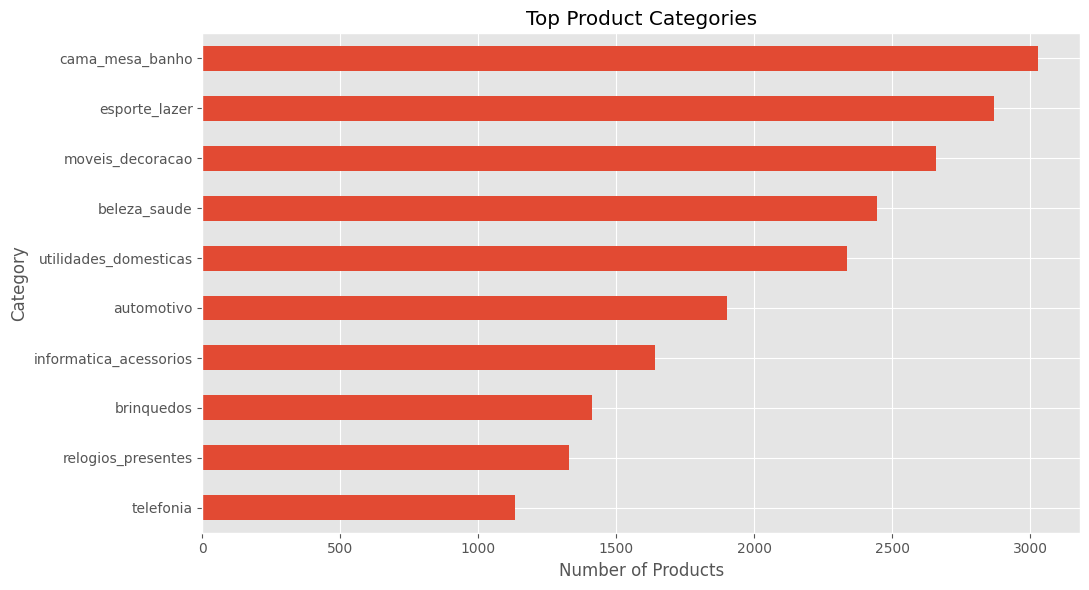

In [5]:
plt.figure(figsize=(11,6))

category_count.sort_values().plot(
    kind="barh"
)

plt.title("Top Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

The marketplace inventory is concentrated in a limited number of product categories. High-volume categories should receive greater attention for inventory management and promotional planning.

In [6]:
product_sales = (
    orderitems
    .merge(
        products,
        on="product_id"
    )
    .merge(
        categories,
        on="product_category_name"
    )
)

average_price = (
    product_sales
    .groupby("product_category_name_english")
    .agg(
        AveragePrice=("price","mean")
    )
    .sort_values(
        by="AveragePrice",
        ascending=False
    )
    .head(10)
)

average_price

,AveragePrice
product_category_name_english,
computers,1098.340542
small_appliances_home_oven_and_coffee,624.285658
home_appliances_2,476.124958
agro_industry_and_commerce,342.124858
musical_instruments,281.616000
small_appliances,280.778468
fixed_telephony,225.693182
construction_tools_safety,208.992371
watches_gifts,201.135984


<Figure size 1200x600 with 0 Axes>

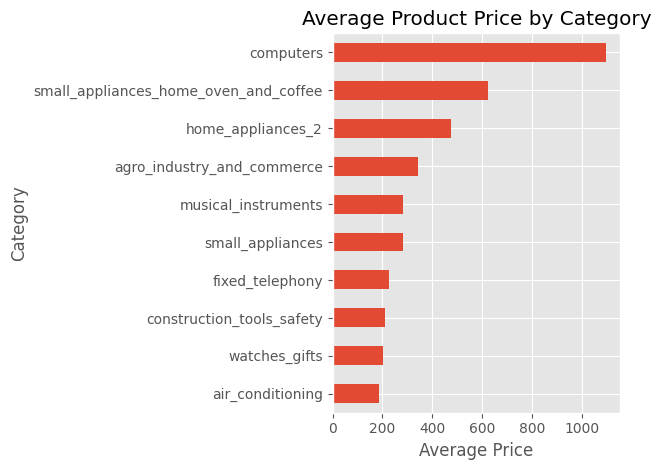

In [7]:
plt.figure(figsize=(12,6))

average_price.sort_values("AveragePrice").plot(
    kind="barh",
    legend=False
)

plt.title("Average Product Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

Premium product categories command significantly higher prices than others. Understanding these categories helps optimize pricing strategies and maximize revenue.

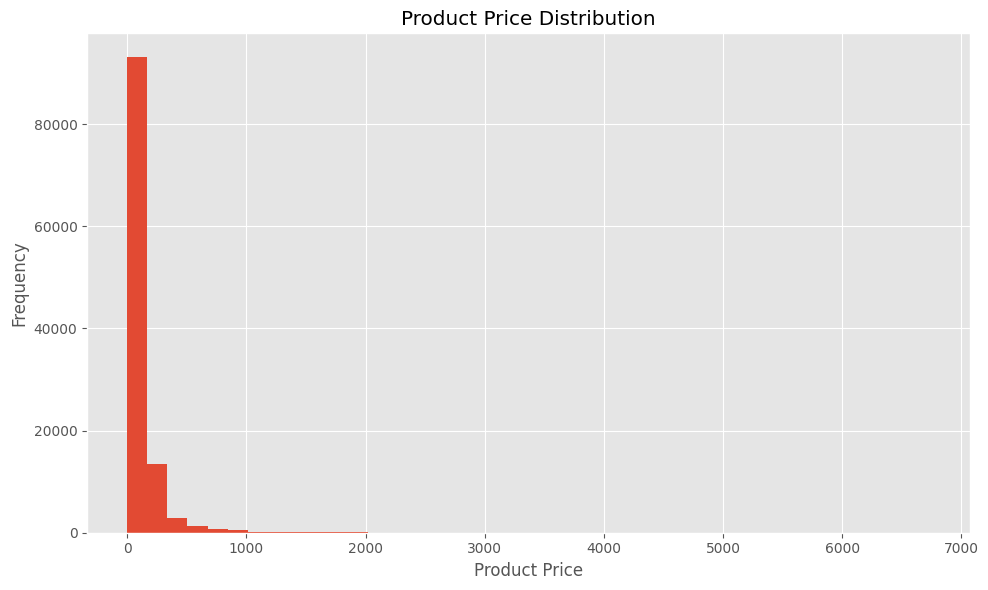

In [8]:
plt.figure(figsize=(10,6))

plt.hist(
    orderitems["price"],
    bins=40
)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

The price distribution reveals the concentration of products across different price ranges. This helps identify whether the marketplace primarily serves budget, mid-range, or premium customers.

## Freight Cost Distribution

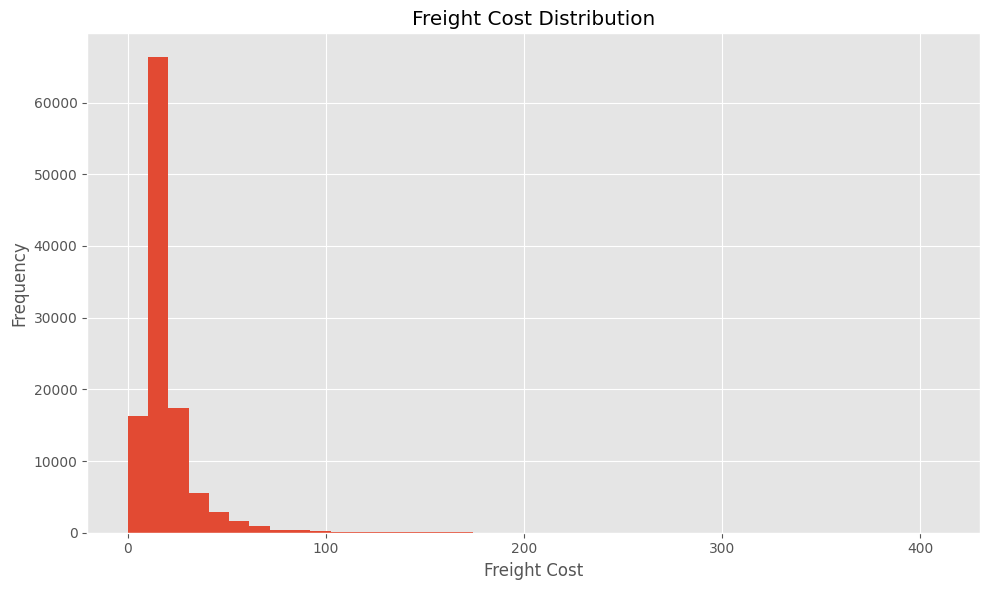

In [9]:
plt.figure(figsize=(10,6))

plt.hist(
    orderitems["freight_value"],
    bins=40
)

plt.title("Freight Cost Distribution")
plt.xlabel("Freight Cost")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Freight charges are concentrated within a relatively small range, indicating consistent shipping costs for most orders. A few orders incur significantly higher logistics expenses.

## Revenue by Product Category

In [10]:
category_revenue = (
    product_sales
    .groupby("product_category_name_english")
    .agg(
        Revenue=("price","sum")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
    .head(10)
)

category_revenue

,Revenue
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


<Figure size 1200x600 with 0 Axes>

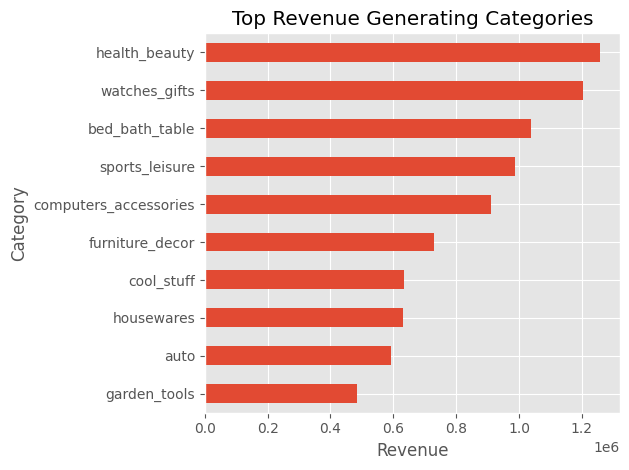

In [11]:
plt.figure(figsize=(12,6))

category_revenue.sort_values("Revenue").plot(
    kind="barh",
    legend=False
)

plt.title("Top Revenue Generating Categories")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

A small number of product categories generate a significant share of marketplace revenue. These categories should remain a priority for inventory allocation, marketing investment, and pricing optimization.

# Key Insights

- Product inventory is concentrated in a limited number of categories.
- Premium categories such as computers generate significantly higher average selling prices.
- Product prices are highly right-skewed, with most products belonging to lower price ranges.
- Revenue is driven by a relatively small number of high-performing product categories.
- Freight costs remain consistent for most orders, with only a few expensive deliveries.

# Business Recommendations

- Prioritize inventory planning for high-demand product categories.
- Apply premium pricing strategies to high-value product segments.
- Increase promotional efforts for profitable categories with consistent demand.
- Review high freight-cost products to optimize logistics expenses.
- Monitor low-performing categories for potential portfolio optimization.